# Robust Cross-Lingual Validation: SynPOS vs MRL-POS

**Purpose:** Validate findings from initial experiments on larger, standard benchmark
datasets used in ACL/NAACL/EMNLP research. Small treebanks (Marathi 373, Tamil 400)
produced noisy results; this notebook uses only datasets with 3K+ sentences.

## Dataset Selection Criteria
1. **Size:** Minimum 3,000 sentences (reliable macro-F1 estimates)
2. **Provenance:** Standard benchmarks cited in top NLP venues
3. **Typological coverage:** Fusional AND agglutinative languages
4. **Script diversity:** Latin, Devanagari, Arabic/Nastaliq, Tamil

## Selected Datasets

| Language | Treebank | Sentences | Tokens | Typology | Script | Standard in |
|----------|----------|-----------|--------|----------|--------|-------------|
| Hindi | UD HDTB | 16,647 | 351K | Fusional | Devanagari | ACL, EMNLP |
| Arabic | UD PADT | 7,664 | 282K | Fusional* | Arabic | ACL, EACL |
| Persian | UD PerDT | 29,107 | 494K | Fusional | Persian | ACL, NAACL |
| Urdu | UD UDTB | 5,130 | 138K | Fusional | Nastaliq | ACL, LREC |
| Turkish | UD IMST | 5,635 | 56K | Agglutinative | Latin | ACL, EMNLP |
| Finnish | UD TDT | 15,136 | 202K | Agglutinative | Latin | ACL, EACL |

*Arabic is technically non-concatenative (root+pattern), a third morphological type.
This makes it a strong test case — neither purely fusional nor agglutinative.

**Controlled experiment:** Same encoder (XLM-R), same co-attention, same gating, same CRF,
same hyperparameters. Only the feature branch and language change.

In [1]:
# Cell 1: Install dependencies
!pip install -q transformers pytorch-crf seqeval regex conllu peft

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaModel, XLMRobertaTokenizer
from torchcrf import CRF
from collections import Counter
from sklearn.metrics import f1_score as sklearn_f1, accuracy_score, classification_report
from transformers import get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model
import numpy as np
import os
import regex
import json
import time
import gc
import glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Cell 3: Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR = '/content/drive/MyDrive/mrl_pos_checkpoints/robust_validation/results'
    os.makedirs(RESULTS_DIR, exist_ok=True)
    print(f"Results: {RESULTS_DIR}")
except:
    RESULTS_DIR = './robust_results'
    os.makedirs(RESULTS_DIR, exist_ok=True)
    print("Not in Colab. Saving locally.")

Mounted at /content/drive
Results: /content/drive/MyDrive/mrl_pos_checkpoints/robust_validation/results


## Configuration

All 6 languages x 2 models x 2 modes = 24 experiments run automatically.
Completed runs (existing JSON) are skipped on rerun.

In [4]:
# Cell 4: Language and experiment configuration

LANG_CONFIG = {
    "hindi": {
        "name": "Hindi",
        "treebank": "UD_Hindi-HDTB",
        "prefix": "hi_hdtb-ud",
        "typology": "fusional",
        "script": "devanagari",
        "family": "Indo-Aryan",
    },
    "arabic": {
        "name": "Arabic",
        "treebank": "UD_Arabic-PADT",
        "prefix": "ar_padt-ud",
        "typology": "non-concatenative",
        "script": "arabic",
        "family": "Semitic",
    },
    "persian": {
        "name": "Persian",
        "treebank": "UD_Persian-PerDT",
        "prefix": "fa_perdt-ud",
        "typology": "fusional",
        "script": "persian",
        "family": "Iranian",
    },
    "urdu": {
        "name": "Urdu",
        "treebank": "UD_Urdu-UDTB",
        "prefix": "ur_udtb-ud",
        "typology": "fusional",
        "script": "nastaliq",
        "family": "Indo-Aryan",
    },
    "turkish": {
        "name": "Turkish",
        "treebank": "UD_Turkish-IMST",
        "prefix": "tr_imst-ud",
        "typology": "agglutinative",
        "script": "latin",
        "family": "Turkic",
    },
    "finnish": {
        "name": "Finnish",
        "treebank": "UD_Finnish-TDT",
        "prefix": "fi_tdt-ud",
        "typology": "agglutinative",
        "script": "latin",
        "family": "Uralic",
    },
}

# All experiment combinations
#hindi"arabic",  done
ALL_RUNS = []
for lang in ["urdu", "persian", "turkish", "finnish"]:
    for model in ["synpos", "mrlpos"]:
        for adapter in [False, True]:
            ALL_RUNS.append((lang, model, adapter))

print(f"Languages: {len(LANG_CONFIG)}")
print(f"Total experiments: {len(ALL_RUNS)}")
for lang, cfg in LANG_CONFIG.items():
    print(f"  {cfg['name']:>10} | {cfg['typology']:<18} | {cfg['family']:<12} | {cfg['treebank']}")

Languages: 6
Total experiments: 16
       Hindi | fusional           | Indo-Aryan   | UD_Hindi-HDTB
      Arabic | non-concatenative  | Semitic      | UD_Arabic-PADT
     Persian | fusional           | Iranian      | UD_Persian-PerDT
        Urdu | fusional           | Indo-Aryan   | UD_Urdu-UDTB
     Turkish | agglutinative      | Turkic       | UD_Turkish-IMST
     Finnish | agglutinative      | Uralic       | UD_Finnish-TDT


## 1. Data Loading

In [5]:
# Cell 5: Data loading with caching
import conllu

def download_ud(language, treebank, prefix):
    base_url = f"https://raw.githubusercontent.com/UniversalDependencies/{treebank}/master"
    splits = {
        "train": f"{prefix}-train.conllu",
        "dev":   f"{prefix}-dev.conllu",
        "test":  f"{prefix}-test.conllu",
    }
    data_dir = f"ud_{language}"
    os.makedirs(data_dir, exist_ok=True)
    for split, fname in splits.items():
        path = f"{data_dir}/{fname}"
        if not os.path.exists(path):
            print(f"    Downloading {split}...")
            !wget -q {base_url}/{fname} -O {path}
            if os.path.getsize(path) == 0:
                print(f"    WARNING: {split} empty or failed")
    return splits, data_dir


def load_conllu(path):
    data = []
    with open(path, 'r') as f:
        for sent in conllu.parse(f.read()):
            words = [tok["form"] for tok in sent if isinstance(tok["id"], int)]
            tags = [tok["upos"] for tok in sent if isinstance(tok["id"], int)]
            if words:
                data.append((words, tags))
    return data


def load_language(language, cfg):
    splits, data_dir = download_ud(language, cfg["treebank"], cfg["prefix"])
    train = load_conllu(f"{data_dir}/{splits['train']}")
    dev   = load_conllu(f"{data_dir}/{splits['dev']}")
    test  = load_conllu(f"{data_dir}/{splits['test']}")

    all_tags = set()
    for _, tags in train + dev + test:
        all_tags.update(tags)
    tag2idx = {"PAD": 0}
    for i, t in enumerate(sorted(all_tags), 1):
        tag2idx[t] = i
    idx2tag = {v: k for k, v in tag2idx.items()}

    total_tokens = sum(len(w) for w, _ in train)
    print(f"  {cfg['name']:>10}: {len(train):>6} train, {len(dev):>5} dev, "
          f"{len(test):>5} test | {total_tokens:>6} tokens | {len(tag2idx)} tags")
    return train, dev, test, tag2idx, idx2tag


_cache = {}
def get_data(language, cfg):
    if language not in _cache:
        _cache[language] = load_language(language, cfg)
    return _cache[language]


# Pre-download all datasets
print("Loading all datasets:")
for lang, cfg in LANG_CONFIG.items():
    get_data(lang, cfg)
print("\nAll datasets loaded and cached.")

Loading all datasets:
       Hindi:  13306 train,  1659 dev,  1684 test | 281057 tokens | 17 tags
      Arabic:   6075 train,   909 dev,   680 test | 223881 tokens | 18 tags
     Persian:  26196 train,  1456 dev,  1455 test | 452496 tokens | 17 tags
        Urdu:   4043 train,   552 dev,   535 test | 108690 tokens | 17 tags
     Turkish:   3435 train,  1100 dev,  1100 test |  37522 tokens | 15 tags
     Finnish:  12217 train,  1364 dev,  1555 test | 162815 tokens | 16 tags

All datasets loaded and cached.


## 2. Model Components

In [6]:
# Cell 6: Script-aware affix extraction

def split_aksharas(word):
    CONSONANTS = set(range(0x0915, 0x093A))
    HALANT = 0x094D
    aksharas = []
    current = ""
    for ch in word:
        cp = ord(ch)
        if cp in CONSONANTS and current:
            if not current.endswith(chr(HALANT)):
                aksharas.append(current)
                current = ""
        current += ch
    if current:
        aksharas.append(current)
    return aksharas if aksharas else list(word)


def split_units(word, script):
    if script == "devanagari":
        return split_aksharas(word)
    else:
        return list(word)


class AffixExtractor:
    def __init__(self, script, max_affixes=8, min_n=2, max_n=5, min_freq=2):
        self.script = script
        self.max_affixes = max_affixes
        self.min_n = min_n
        self.max_n = max_n
        self.min_freq = min_freq
        self.ngram2idx = {"<pad>": 0, "<unk>": 1}
        self.idx = 2

    def build_vocab(self, sentences):
        counts = Counter()
        for words in sentences:
            for word in words:
                units = split_units(word, self.script)
                for n in range(self.min_n, self.max_n + 1):
                    if n <= len(units):
                        counts["".join(units[:n])] += 1
                        counts["".join(units[-n:])] += 1
        for ng, freq in counts.items():
            if freq >= self.min_freq and ng not in self.ngram2idx:
                self.ngram2idx[ng] = self.idx
                self.idx += 1

    def extract(self, word):
        units = split_units(word, self.script)
        indices = []
        for n in range(self.min_n, self.max_n + 1):
            if n <= len(units):
                indices.append(self.ngram2idx.get("".join(units[:n]), 1))
                indices.append(self.ngram2idx.get("".join(units[-n:]), 1))
        return indices[:self.max_affixes]


print("AffixExtractor defined.")

AffixExtractor defined.


In [7]:
# Cell 7: Local Context CNN Branch

class LocalContextBranch(nn.Module):
    def __init__(self, input_dim=768, output_dim=768, kernel_sizes=(1, 2, 3)):
        super().__init__()
        ch = output_dim // len(kernel_sizes)
        rem = output_dim - ch * len(kernel_sizes)
        self.convs = nn.ModuleList()
        for i, ks in enumerate(kernel_sizes):
            self.convs.append(nn.Conv1d(input_dim, ch + (1 if i < rem else 0), ks, padding=ks//2))
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, h, mask):
        x = h.transpose(1, 2)
        outs = [F.gelu(c(x))[:, :, :h.size(1)] for c in self.convs]
        h_syn = torch.cat(outs, dim=1).transpose(1, 2)
        return self.dropout(self.norm(h_syn * mask.unsqueeze(-1).float()))

print("LocalContextBranch defined.")

LocalContextBranch defined.


In [8]:
# Cell 8: Shared model components

class AffixEmbeddingModule(nn.Module):
    def __init__(self, vocab_size, affix_dim=128, hidden_dim=128, output_dim=768, max_affixes=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, affix_dim, padding_idx=0)
        self.pos_enc = nn.Embedding(max_affixes, affix_dim)
        self.bilstm = nn.LSTM(affix_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.proj = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, ids):
        B, S, M = ids.shape
        flat = ids.view(B*S, M)
        pos = torch.arange(M, device=ids.device).unsqueeze(0).expand(B*S, -1)
        H, _ = self.bilstm(self.embedding(flat) + self.pos_enc(pos))
        sc = self.attn(H).squeeze(-1).masked_fill(flat == 0, -1e9)
        beta = F.softmax(sc, dim=-1)
        return self.proj((beta.unsqueeze(-1) * H).sum(1)).view(B, S, -1)


class LayerWiseAttentionPooling(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.w = nn.Linear(dim, 1)

    def forward(self, states):
        s = torch.stack(states[1:], dim=2)
        a = F.softmax(self.w(s).squeeze(-1), dim=-1)
        return (a.unsqueeze(-1) * s).sum(2)


class DualGatingCoAttention(nn.Module):
    def __init__(self, d=768):
        super().__init__()
        self.W_a2c = nn.Linear(2*d, d)
        self.W_c2a = nn.Linear(2*d, d)
        self.fuse = nn.Linear(2*d, d)

    def forward(self, Hc, Ha):
        cat = torch.cat([Hc, Ha], -1)
        return self.fuse(torch.cat([
            torch.sigmoid(self.W_a2c(cat)) * Hc,
            torch.sigmoid(self.W_c2a(cat)) * Ha
        ], -1))

print("Shared components defined.")

Shared components defined.


In [9]:
# Cell 9: Model classes

class MRLPOS(nn.Module):
    def __init__(self, affix_vocab, num_tags, dim=768, max_aff=8, use_lora=False):
        super().__init__()
        self.xlmr = XLMRobertaModel.from_pretrained("xlm-roberta-base", output_hidden_states=True)
        if use_lora:
            self.xlmr = get_peft_model(self.xlmr, LoraConfig(
                r=16, lora_alpha=32, target_modules=["query","value"],
                lora_dropout=0.1, bias="none"))
        self.pool = LayerWiseAttentionPooling(dim)
        self.affix = AffixEmbeddingModule(affix_vocab, output_dim=dim, max_affixes=max_aff)
        self.coattn = DualGatingCoAttention(dim)
        self.cls = nn.Linear(dim, num_tags)
        self.crf = CRF(num_tags, batch_first=True)

    def forward(self, ids, mask, aff=None, tags=None):
        out = self.xlmr(input_ids=ids, attention_mask=mask)
        hs = out.hidden_states if hasattr(out, 'hidden_states') else out[2]
        Hc = self.pool(hs)
        Ha = self.affix(aff)
        em = self.cls(self.coattn(Hc, Ha))
        return -self.crf(em, tags, mask=mask.bool()) if tags is not None else self.crf.decode(em, mask=mask.bool())


class SynPOS(nn.Module):
    def __init__(self, num_tags, dim=768, use_lora=False):
        super().__init__()
        self.xlmr = XLMRobertaModel.from_pretrained("xlm-roberta-base", output_hidden_states=True)
        if use_lora:
            self.xlmr = get_peft_model(self.xlmr, LoraConfig(
                r=16, lora_alpha=32, target_modules=["query","value"],
                lora_dropout=0.1, bias="none"))
        self.pool = LayerWiseAttentionPooling(dim)
        self.syn = LocalContextBranch(dim, dim)
        self.coattn = DualGatingCoAttention(dim)
        self.cls = nn.Linear(dim, num_tags)
        self.crf = CRF(num_tags, batch_first=True)

    def forward(self, ids, mask, tags=None):
        out = self.xlmr(input_ids=ids, attention_mask=mask)
        hs = out.hidden_states if hasattr(out, 'hidden_states') else out[2]
        Hc = self.pool(hs)
        Hs = self.syn(Hc, mask)
        em = self.cls(self.coattn(Hc, Hs))
        return -self.crf(em, tags, mask=mask.bool()) if tags is not None else self.crf.decode(em, mask=mask.bool())


print("MRLPOS and SynPOS defined.")

MRLPOS and SynPOS defined.


In [10]:
# Cell 10: Dataset classes

class MRLDataset(Dataset):
    def __init__(self, data, tok, ext, t2i, ml=128):
        self.data, self.tok, self.ext, self.t2i, self.ml = data, tok, ext, t2i, ml
        self.ma = ext.max_affixes

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        w, t = self.data[i]
        enc = self.tok(w, is_split_into_words=True, padding="max_length",
                       truncation=True, max_length=self.ml, return_tensors="pt")
        ids = enc["input_ids"].squeeze(0)
        mask = enc["attention_mask"].squeeze(0)
        wids = enc.word_ids()
        tags, affs = [], []
        prev = None
        for j, wid in enumerate(wids):
            if wid is None:
                tags.append(0); affs.append([0]*self.ma)
            elif wid != prev:
                tg = t[wid] if t[wid] in self.t2i else "X"
                tags.append(self.t2i.get(tg, self.t2i.get("X", 0)))
                ai = self.ext.extract(w[wid])
                affs.append((ai + [0]*self.ma)[:self.ma])
            else:
                tags.append(0); affs.append([0]*self.ma)
            prev = wid
        return {"input_ids": ids, "attention_mask": mask,
                "affix_ids": torch.tensor(affs, dtype=torch.long),
                "tags": torch.tensor(tags, dtype=torch.long)}


class SynDataset(Dataset):
    def __init__(self, data, tok, t2i, ml=128):
        self.data, self.tok, self.t2i, self.ml = data, tok, t2i, ml

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        w, t = self.data[i]
        enc = self.tok(w, is_split_into_words=True, padding="max_length",
                       truncation=True, max_length=self.ml, return_tensors="pt")
        ids = enc["input_ids"].squeeze(0)
        mask = enc["attention_mask"].squeeze(0)
        wids = enc.word_ids()
        tags = []
        prev = None
        for j, wid in enumerate(wids):
            if wid is None: tags.append(0)
            elif wid != prev:
                tg = t[wid] if t[wid] in self.t2i else "X"
                tags.append(self.t2i.get(tg, self.t2i.get("X", 0)))
            else: tags.append(0)
            prev = wid
        return {"input_ids": ids, "attention_mask": mask,
                "tags": torch.tensor(tags, dtype=torch.long)}


print("Dataset classes defined.")

Dataset classes defined.


## 3. Training Loop

All 24 experiments run sequentially. Completed runs are skipped.

In [11]:
# Cell 11: Training loop

tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

BATCH = 64
EPOCHS = 30
PATIENCE = 7
WARMUP = 0.15
ML = 128


def result_path(lang, model, lora):
    return os.path.join(RESULTS_DIR, f"{lang}_{model}_{'lora' if lora else 'full'}.json")


def run_experiment(lang, model_type, lora):
    cfg = LANG_CONFIG[lang]
    mode = "lora" if lora else "full"
    enc_lr = 3e-4 if lora else 1e-5
    head_lr = 1e-3

    train_data, dev_data, _, t2i, i2t = get_data(lang, cfg)

    # Affix extractor
    aext = None
    if model_type == "mrlpos":
        aext = AffixExtractor(script=cfg["script"])
        aext.build_vocab([s for s, _ in train_data])

    # Datasets
    if model_type == "mrlpos":
        tds = MRLDataset(train_data, tokenizer, aext, t2i, ML)
        dds = MRLDataset(dev_data, tokenizer, aext, t2i, ML)
    else:
        tds = SynDataset(train_data, tokenizer, t2i, ML)
        dds = SynDataset(dev_data, tokenizer, t2i, ML)

    tdl = DataLoader(tds, batch_size=BATCH, shuffle=True)
    ddl = DataLoader(dds, batch_size=BATCH)

    # Model
    if model_type == "mrlpos":
        mdl = MRLPOS(aext.idx, len(t2i), use_lora=lora).to(device)
    else:
        mdl = SynPOS(len(t2i), use_lora=lora).to(device)

    tp = sum(p.numel() for p in mdl.parameters())
    trp = sum(p.numel() for p in mdl.parameters() if p.requires_grad)

    # Optimizer
    if lora:
        ep = [p for n, p in mdl.named_parameters() if "xlmr" in n and p.requires_grad]
        hp = [p for n, p in mdl.named_parameters() if "xlmr" not in n and p.requires_grad]
    else:
        ep = list(mdl.xlmr.parameters())
        hp = [p for n, p in mdl.named_parameters() if not n.startswith("xlmr.")]

    opt = torch.optim.AdamW([{"params": ep, "lr": enc_lr}, {"params": hp, "lr": head_lr}])
    ts = len(tdl) * EPOCHS
    sched = get_cosine_schedule_with_warmup(opt, int(ts * WARMUP), ts)

    print(f"  {trp:,} trainable / {tp:,} total | {len(tdl)*EPOCHS} steps")

    def evaluate():
        mdl.eval()
        ap, ag = [], []
        with torch.no_grad():
            for b in ddl:
                if model_type == "mrlpos":
                    pr = mdl(b["input_ids"].to(device), b["attention_mask"].to(device),
                             b["affix_ids"].to(device))
                else:
                    pr = mdl(b["input_ids"].to(device), b["attention_mask"].to(device))
                for bi in range(len(pr)):
                    for p, g, m in zip(pr[bi], b["tags"][bi], b["attention_mask"][bi]):
                        if m.item() == 1 and g.item() != 0:
                            ap.append(p); ag.append(g.item())
        return accuracy_score(ag, ap), sklearn_f1(ag, ap, average="macro", zero_division=0), ap, ag

    best_f1, best_st, noimp, log = 0, None, 0, []
    t0 = time.time()

    for ep in range(EPOCHS):
        mdl.train()
        tloss = 0
        for b in tdl:
            opt.zero_grad()
            if model_type == "mrlpos":
                loss = mdl(b["input_ids"].to(device), b["attention_mask"].to(device),
                           b["affix_ids"].to(device), tags=b["tags"].to(device))
            else:
                loss = mdl(b["input_ids"].to(device), b["attention_mask"].to(device),
                           tags=b["tags"].to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            opt.step(); sched.step()
            tloss += loss.item()

        acc, f1, _, _ = evaluate()
        print(f"    Ep {ep+1:2d} | Loss: {tloss/len(tdl):.4f} | Acc: {acc:.4f} | F1: {f1:.4f} | {time.time()-t0:.0f}s")
        log.append({"epoch": ep+1, "loss": round(tloss/len(tdl),4), "acc": round(acc,4), "f1": round(f1,4)})

        if f1 > best_f1:
            best_f1 = f1; noimp = 0
            best_st = {k: v.cpu().clone() for k, v in mdl.state_dict().items()}
        else:
            noimp += 1
            if noimp >= PATIENCE:
                print(f"    Early stop. Best F1: {best_f1:.4f}")
                break

    tt = time.time() - t0

    # Final eval
    mdl.load_state_dict(best_st); mdl.to(device)
    acc, f1, ap, ag = evaluate()
    gl = [i2t[g] for g in ag]; pl = [i2t[p] for p in ap]
    dtags = sorted(set(gl))
    ptf = {}
    for tag in dtags:
        bg = [1 if g==tag else 0 for g in gl]
        bp = [1 if p==tag else 0 for p in pl]
        ptf[tag] = round(sklearn_f1(bg, bp, zero_division=0), 4)
    mf1c = round(np.mean(list(ptf.values())), 4)

    print(f"    FINAL: Acc={acc:.4f}, Macro-F1={mf1c:.4f}, Time={tt:.0f}s")

    res = {
        "language": lang, "language_name": cfg["name"], "typology": cfg["typology"],
        "family": cfg["family"], "model_type": model_type,
        "adapter_mode": lora, "mode_tag": mode,
        "best_f1": round(best_f1,4), "macro_f1_clean": mf1c, "accuracy": round(acc,4),
        "per_tag_f1": ptf, "train_size": len(train_data), "dev_size": len(dev_data),
        "num_tags": len(t2i), "total_params": tp, "trainable_params": trp,
        "training_time_s": round(tt,1), "training_log": log,
    }
    del mdl, opt, sched, best_st; torch.cuda.empty_cache(); gc.collect()
    return res


# === MAIN LOOP ===
print(f"{'='*70}")
print(f"RUNNING {len(ALL_RUNS)} EXPERIMENTS")
print(f"{'='*70}")

done, skip = 0, 0
for ri, (lang, mt, lora) in enumerate(ALL_RUNS):
    mode = "lora" if lora else "full"
    rp = result_path(lang, mt, lora)
    cfg = LANG_CONFIG[lang]

    print(f"\n[{ri+1}/{len(ALL_RUNS)}] {cfg['name']} / {mt.upper()} / {mode}")
    print("-" * 50)

    if os.path.exists(rp):
        with open(rp) as f: ex = json.load(f)
        print(f"  SKIP (F1={ex.get('macro_f1_clean','?')})")
        skip += 1; continue

    try:
        res = run_experiment(lang, mt, lora)
        with open(rp, 'w') as f: json.dump(res, f, indent=2)
        print(f"  SAVED: {os.path.basename(rp)}")
        done += 1
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()
        torch.cuda.empty_cache(); gc.collect()

print(f"\n{'='*70}")
print(f"DONE: {done} completed, {skip} skipped, {len(ALL_RUNS)-done-skip} failed")
print(f"{'='*70}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RUNNING 16 EXPERIMENTS

[1/16] Urdu / SYNPOS / full
--------------------------------------------------


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  285,949,745 trainable / 285,949,745 total | 5730 steps
    Ep  1 | Loss: 1995.8142 | Acc: 0.9473 | F1: 0.7391 | 340s
    Ep  2 | Loss: 118.6092 | Acc: 0.9737 | F1: 0.8106 | 681s
    Ep  3 | Loss: 72.1724 | Acc: 0.9789 | F1: 0.9092 | 1021s
    Ep  4 | Loss: 52.7865 | Acc: 0.9807 | F1: 0.9295 | 1361s
    Ep  5 | Loss: 39.3953 | Acc: 0.9839 | F1: 0.9385 | 1699s
    Ep  6 | Loss: 29.0363 | Acc: 0.9829 | F1: 0.8783 | 2039s
    Ep  7 | Loss: 20.1948 | Acc: 0.9830 | F1: 0.9410 | 2378s
    Ep  8 | Loss: 15.9386 | Acc: 0.9837 | F1: 0.9448 | 2717s
    Ep  9 | Loss: 11.5458 | Acc: 0.9825 | F1: 0.8832 | 3057s
    Ep 10 | Loss: 9.6205 | Acc: 0.9823 | F1: 0.9262 | 3396s
    Ep 11 | Loss: 7.6959 | Acc: 0.9836 | F1: 0.9464 | 3734s
    Ep 12 | Loss: 6.5194 | Acc: 0.9836 | F1: 0.8839 | 4073s
    Ep 13 | Loss: 5.8320 | Acc: 0.9837 | F1: 0.9481 | 4412s
    Ep 14 | Loss: 5.0387 | Acc: 0.9843 | F1: 0.9428 | 4752s
    Ep 15 | Loss: 3.9191 | Acc: 0.9832 | F1: 0.9456 | 5090s
    Ep 16 | Loss: 3.7519 | Acc: 0

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  8,495,921 trainable / 286,539,569 total | 5730 steps
    Ep  1 | Loss: 1914.7680 | Acc: 0.9580 | F1: 0.7528 | 256s
    Ep  2 | Loss: 110.1796 | Acc: 0.9746 | F1: 0.8348 | 514s
    Ep  3 | Loss: 76.3352 | Acc: 0.9786 | F1: 0.8611 | 772s
    Ep  4 | Loss: 59.0557 | Acc: 0.9811 | F1: 0.8720 | 1029s
    Ep  5 | Loss: 44.7824 | Acc: 0.9809 | F1: 0.9233 | 1286s
    Ep  6 | Loss: 33.4818 | Acc: 0.9826 | F1: 0.9363 | 1544s
    Ep  7 | Loss: 25.4659 | Acc: 0.9819 | F1: 0.9406 | 1801s
    Ep  8 | Loss: 20.1666 | Acc: 0.9811 | F1: 0.8657 | 2059s
    Ep  9 | Loss: 16.0796 | Acc: 0.9821 | F1: 0.8780 | 2316s
    Ep 10 | Loss: 12.7804 | Acc: 0.9829 | F1: 0.9534 | 2572s
    Ep 11 | Loss: 10.8931 | Acc: 0.9828 | F1: 0.8863 | 2829s
    Ep 12 | Loss: 9.1975 | Acc: 0.9830 | F1: 0.9514 | 3086s
    Ep 13 | Loss: 7.3863 | Acc: 0.9829 | F1: 0.8816 | 3342s
    Ep 14 | Loss: 6.0740 | Acc: 0.9836 | F1: 0.9494 | 3598s
    Ep 15 | Loss: 5.5938 | Acc: 0.9835 | F1: 0.9536 | 3853s
    Ep 16 | Loss: 4.5703 | Acc: 0.

## 4. Results Aggregation

In [12]:
# Cell 12: Aggregate all results

rfiles = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.json")))
print(f"Found {len(rfiles)} result files:\n")

results = []
for rf in rfiles:
    with open(rf) as f: results.append(json.load(f))
    print(f"  {os.path.basename(rf)}")

if len(results) < 2:
    print("\nNeed more results.")
else:
    LANGS = ["hindi", "arabic", "persian", "urdu", "turkish", "finnish"]

    by_lm = {}
    for r in results:
        key = (r["language"], r.get("mode_tag", "full"))
        by_lm.setdefault(key, {})[r["model_type"]] = r

    for ml, mk in [("FULL FINE-TUNING", "full"), ("LoRA ADAPTERS", "lora")]:
        mr = {k: v for k, v in by_lm.items() if k[1] == mk}
        if not mr: continue

        print(f"\n{'='*95}")
        print(f"EXPERIMENT: {ml}")
        print(f"{'='*95}")
        print(f"{'Language':<10} {'Typology':<18} {'Family':<12} {'Train':<7} "
              f"{'MRL-POS':<10} {'SynPOS':<10} {'Delta':<9} {'Winner':<10}")
        print("-" * 95)

        for lang in LANGS:
            key = (lang, mk)
            if key not in by_lm: continue
            lr = by_lm[key]
            r0 = lr[list(lr.keys())[0]]
            mf = lr.get("mrlpos", {}).get("macro_f1_clean")
            sf = lr.get("synpos", {}).get("macro_f1_clean")
            ms = f"{mf:.4f}" if mf else "—"
            ss = f"{sf:.4f}" if sf else "—"
            if mf and sf:
                d = sf - mf
                ds = f"{d:+.4f}"
                w = "TIE" if abs(d) < 0.005 else ("SynPOS" if d > 0 else "MRL-POS")
            else:
                ds, w = "—", "pending"
            print(f"{r0['language_name']:<10} {r0['typology']:<18} {r0['family']:<12} "
                  f"{r0['train_size']:<7} {ms:<10} {ss:<10} {ds:<9} {w:<10}")
        print("-" * 95)

    # Hypothesis
    print(f"\n{'='*70}")
    print("HYPOTHESIS CHECK (robust datasets only)")
    print(f"{'='*70}")
    confirmed = 0; total = 0
    for (lang, mode), lr in sorted(by_lm.items()):
        if "mrlpos" in lr and "synpos" in lr:
            typ = lr["mrlpos"]["typology"]
            m = lr["mrlpos"]["macro_f1_clean"]
            s = lr["synpos"]["macro_f1_clean"]
            # fusional/non-concat -> expect synpos, agglutinative -> expect mrlpos
            exp = "synpos" if typ in ["fusional", "non-concatenative"] else "mrlpos"
            act = "synpos" if s > m else ("tie" if abs(s-m) < 0.005 else "mrlpos")
            ok = "CONFIRMED" if exp == act or act == "tie" else "MIXED"
            if ok == "CONFIRMED": confirmed += 1
            total += 1
            print(f"  {lr['mrlpos']['language_name']:>10} ({typ:>18}, {mode:>4}): "
                  f"MRL={m:.4f} SYN={s:.4f} -> {ok}")
    print(f"\n  Score: {confirmed}/{total} confirmed")

Found 24 result files:

  arabic_mrlpos_full.json
  arabic_mrlpos_lora.json
  arabic_synpos_full.json
  arabic_synpos_lora.json
  finnish_mrlpos_full.json
  finnish_mrlpos_lora.json
  finnish_synpos_full.json
  finnish_synpos_lora.json
  hindi_mrlpos_full.json
  hindi_mrlpos_lora.json
  hindi_synpos_full.json
  hindi_synpos_lora.json
  persian_mrlpos_full.json
  persian_mrlpos_lora.json
  persian_synpos_full.json
  persian_synpos_lora.json
  turkish_mrlpos_full.json
  turkish_mrlpos_lora.json
  turkish_synpos_full.json
  turkish_synpos_lora.json
  urdu_mrlpos_full.json
  urdu_mrlpos_lora.json
  urdu_synpos_full.json
  urdu_synpos_lora.json

EXPERIMENT: FULL FINE-TUNING
Language   Typology           Family       Train   MRL-POS    SynPOS     Delta     Winner    
-----------------------------------------------------------------------------------------------
Hindi      fusional           Indo-Aryan   13306   0.9319     0.9269     -0.0050   MRL-POS   
Arabic     non-concatenative  Semitic 

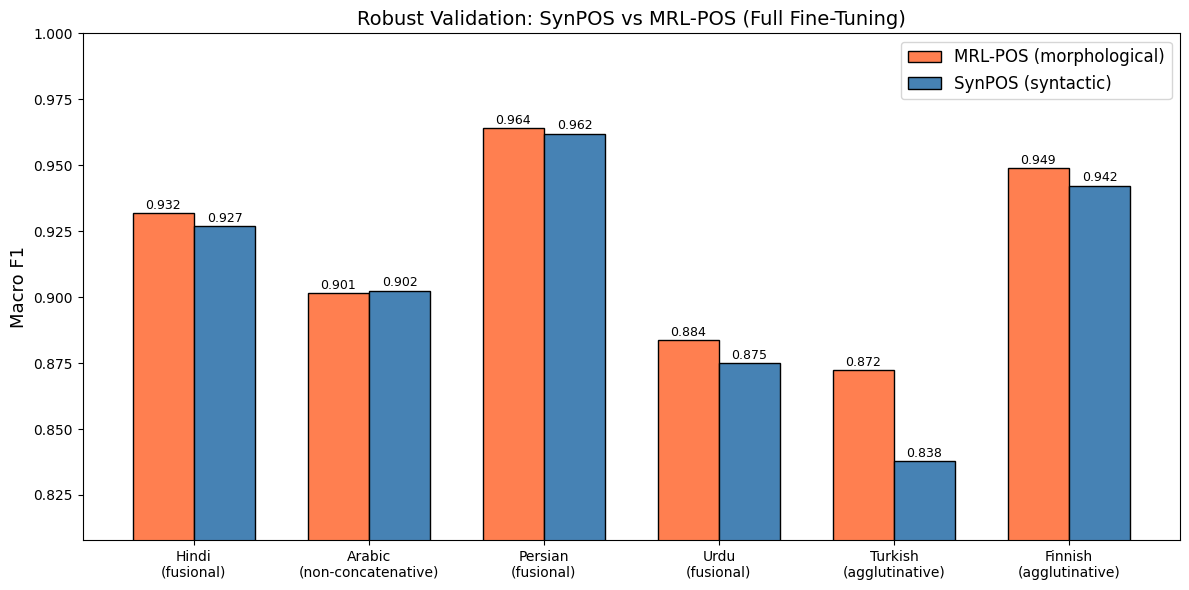

Saved: robust_full.png


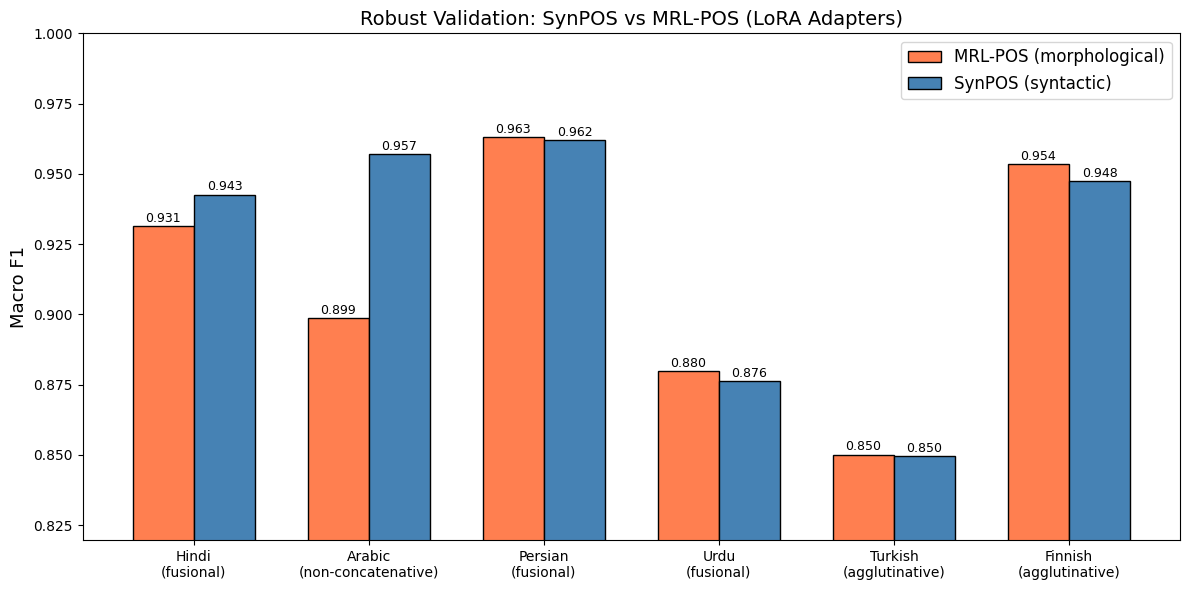

Saved: robust_lora.png

FULL vs LoRA: Does adapter mode amplify branch differences?
Language   Full MRL  Full SYN  Full D   LoRA MRL  LoRA SYN  LoRA D   Amplified?
--------------------------------------------------------------------------------
Hindi      0.9319    0.9269    -0.0050  0.9313    0.9426    +0.0113  YES
Arabic     0.9014    0.9025    +0.0011  0.8988    0.9571    +0.0583  YES
Persian    0.9641    0.9620    -0.0021  0.9631    0.9620    -0.0011  no
Urdu       0.8838    0.8750    -0.0088  0.8799    0.8764    -0.0035  no
Turkish    0.8722    0.8379    -0.0343  0.8501    0.8497    -0.0004  no
Finnish    0.9490    0.9423    -0.0067  0.9536    0.9475    -0.0061  no
--------------------------------------------------------------------------------


In [13]:
# Cell 13: Visualization
import matplotlib.pyplot as plt

LANGS = ["hindi", "arabic", "persian", "urdu", "turkish", "finnish"]

for ml, mk in [("Full Fine-Tuning", "full"), ("LoRA Adapters", "lora")]:
    mr = {k: v for k, v in by_lm.items() if k[1] == mk}
    if not mr: continue

    names, ms, ss, typs = [], [], [], []
    for lang in LANGS:
        key = (lang, mk)
        if key in by_lm and "mrlpos" in by_lm[key] and "synpos" in by_lm[key]:
            lr = by_lm[key]
            names.append(lr["mrlpos"]["language_name"])
            ms.append(lr["mrlpos"]["macro_f1_clean"])
            ss.append(lr["synpos"]["macro_f1_clean"])
            typs.append(lr["mrlpos"]["typology"])

    if not names: continue

    fig, ax = plt.subplots(figsize=(max(10, len(names)*2), 6))
    x = np.arange(len(names))
    w = 0.35
    b1 = ax.bar(x-w/2, ms, w, label='MRL-POS (morphological)', color='coral', edgecolor='black')
    b2 = ax.bar(x+w/2, ss, w, label='SynPOS (syntactic)', color='steelblue', edgecolor='black')
    ax.set_ylabel('Macro F1', fontsize=13)
    ax.set_title(f'Robust Validation: SynPOS vs MRL-POS ({ml})', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{n}\n({t})" for n, t in zip(names, typs)], fontsize=10)
    ax.legend(fontsize=12)
    ax.set_ylim(min(ms+ss)-0.03, 1.0)
    for b in list(b1)+list(b2):
        ax.annotate(f'{b.get_height():.3f}', xy=(b.get_x()+b.get_width()/2, b.get_height()),
                   xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)
    plt.tight_layout()
    fn = f"robust_{mk}.png"
    plt.savefig(os.path.join(RESULTS_DIR, fn), dpi=150)
    plt.show()
    print(f"Saved: {fn}")

# Full vs LoRA comparison
fl = {k[0] for k in by_lm if k[1]=="full"}
ll = {k[0] for k in by_lm if k[1]=="lora"}
bl = fl & ll
if bl:
    print(f"\n{'='*80}")
    print("FULL vs LoRA: Does adapter mode amplify branch differences?")
    print(f"{'='*80}")
    print(f"{'Language':<10} {'Full MRL':<9} {'Full SYN':<9} {'Full D':<8} "
          f"{'LoRA MRL':<9} {'LoRA SYN':<9} {'LoRA D':<8} {'Amplified?'}")
    print("-"*80)
    for lang in LANGS:
        if lang not in bl: continue
        f = by_lm[(lang,"full")]; l = by_lm[(lang,"lora")]
        if not all(k in f and k in l for k in ["mrlpos","synpos"]): continue
        fm,fs = f["mrlpos"]["macro_f1_clean"], f["synpos"]["macro_f1_clean"]
        lm,ls = l["mrlpos"]["macro_f1_clean"], l["synpos"]["macro_f1_clean"]
        fd, ld = fs-fm, ls-lm
        amp = "YES" if abs(ld) > abs(fd)+0.005 else "no"
        print(f"{f['mrlpos']['language_name']:<10} {fm:<9.4f} {fs:<9.4f} {fd:<+8.4f} "
              f"{lm:<9.4f} {ls:<9.4f} {ld:<+8.4f} {amp}")
    print("-"*80)

## 5. Summary

This notebook validates findings using only **large, standard benchmark datasets** (3K+ sentences)
from Universal Dependencies, eliminating noise from small treebanks.

**Key differences from initial experiments:**
- Removed Marathi (373 sentences) and Tamil (400) — too small for reliable conclusions
- Added Arabic-PADT (7.6K) — non-concatenative morphology, tests a third typological category
- Added Persian-PerDT (29K) — largest dataset, fusional, strong confidence in results

**Languages tested:**
| Language | Family | Typology | Sentences | Standard benchmark for |
|----------|--------|----------|-----------|----------------------|
| Hindi | Indo-Aryan | Fusional | 16,647 | South Asian NLP |
| Arabic | Semitic | Non-concatenative | 7,664 | Arabic NLP (ACL, EACL) |
| Persian | Iranian | Fusional | 29,107 | Iranian NLP (ACL) |
| Urdu | Indo-Aryan | Fusional | 5,130 | South Asian NLP |
| Turkish | Turkic | Agglutinative | 5,635 | Turkic NLP (ACL, EMNLP) |
| Finnish | Uralic | Agglutinative | 15,136 | Nordic/Uralic NLP (ACL, EACL) |